# INTRODUCTION

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">In today's competitive financial sector, marketing campaigns play a crucial role in attracting and retaining customers. Financial institutions invest significant resources in telemarketing and promotional activities to encourage customers to subscribe to banking products and services. However, not every campaign achieves the desired results, making it essential to understand the factors that influence customer responses.

This Exploratory Data Analysis (EDA) project aims to analyze the historical marketing campaign data of a financial institution using Python's Data Science ecosystem, including Pandas, NumPy, Matplotlib, and Seaborn. By examining customer demographics, campaign characteristics, and previous interactions, the project seeks to uncover meaningful patterns, trends, and relationships that contribute to the success or failure of marketing efforts.

Through data cleaning, statistical analysis, and visualization techniques, this study provides valuable insights into customer behavior and campaign performance. The findings will help identify key drivers of successful marketing strategies and support data-driven decision-making for future campaigns.

The dataset used in this project is based on the research paper, *"A Data-Driven Approach to Predict the Success of Bank Telemarketing"* by Moro, Cortez, and Rita (2014), published in *Decision Support Systems*. It contains information collected from direct marketing campaigns conducted by a Portuguese banking institution, offering a rich foundation for understanding customer engagement and marketing effectiveness.


# OBJECTIVES:

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">
<ul>


<li>To perform comprehensive data cleaning and preprocessing to ensure the quality and consistency of the dataset.
<li>To analyze customer demographic attributes such as age, occupation, marital status, and education level.
<li>To investigate the impact of campaign-related factors, including contact duration, number of contacts, and previous campaign outcomes.
<li>To identify patterns and trends associated with customers who subscribed to the bank's marketing offer.
<li>To explore relationships between customer characteristics and campaign success using statistical methods and visualizations.
<li>To create informative visualizations using Matplotlib and Seaborn for better interpretation of the data.
<li>To evaluate the effectiveness of previous marketing campaigns and determine factors influencing their outcomes.
<li>To provide actionable insights and recommendations that can help financial institutions optimize future marketing strategies.
<li>To demonstrate the practical application of Python Data Science libraries in solving real-world business problems through Exploratory Data Analysis.

</ul>
</div>

# 1. Getting Ready with Dataset

In [1]:
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
        

In [2]:
data = pl.read_csv('/home/kartika/Datasets/bankmarketing.csv')
data = data.to_pandas()
data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [4]:
data.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

In [5]:
data.duplicated().sum()

np.int64(0)

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">No null values and duplicate rows.

<div>

# 2. Univariate Analysis

## 2.1 Demographic Attributes

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Describes the personal and social characteristics of customer.

In [6]:
data['age'].describe()

count    11162.000000
mean        41.231948
std         11.913369
min         18.000000
25%         32.000000
50%         39.000000
75%         49.000000
max         95.000000
Name: age, dtype: float64

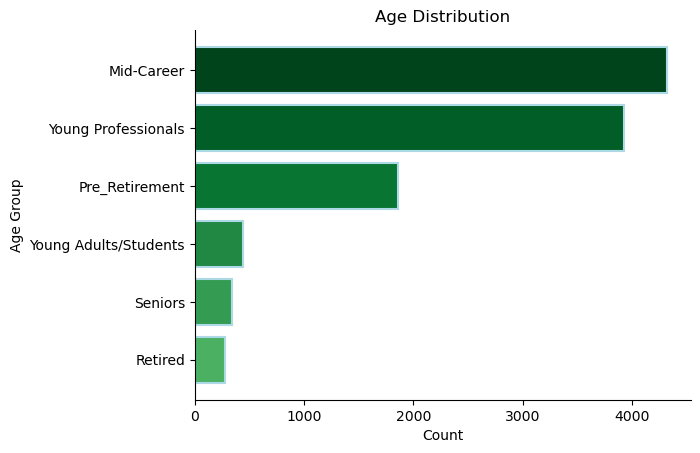

In [7]:

bins =  [18, 25, 35, 50, 60, 70, 96 ]
labels = ['Young Adults/Students', 'Young Professionals',
            'Mid-Career', 'Pre_Retirement', 'Seniors', 'Retired']

data['age_category'] = pd.cut(data['age'], bins = bins,
                            labels = labels )

plt.barh(
    y = data['age_category'].value_counts().index,
    width = data['age_category'].value_counts().values,
    color = plt.cm.Greens(np.linspace(1, 0.6, 6)),
    linewidth = 1.5,
    edgecolor = 'lightblue'
)

plt.title('Age Distribution')
plt.ylabel('Age Group')
plt.xlabel('Count')
sns.despine()
plt.gca().invert_yaxis()
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Most of the customers are Mid-career and Young Professionals.

<div>

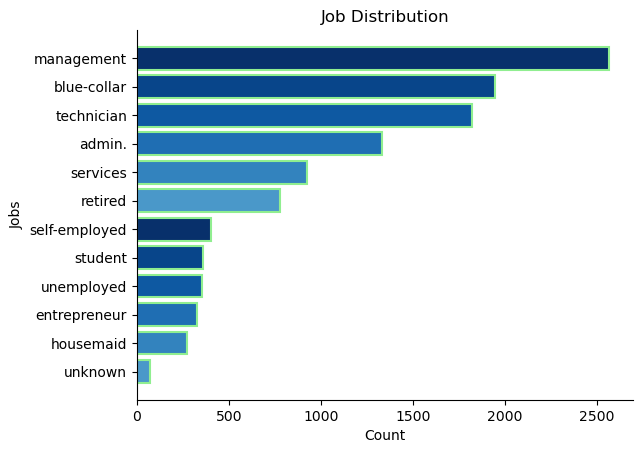

In [8]:
plt.barh(
    y  = data['job'].value_counts().index,
    width = data['job'].value_counts().values,
    color  = plt.cm.Blues(np.linspace(1, 0.6, 6)),
    linewidth = 1.5,
    edgecolor = 'lightgreen'
)

plt.title('Job Distribution'
)
plt.ylabel('Jobs')
plt.xlabel('Count')
plt.gca().invert_yaxis()
sns.despine()
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Most of the customers do management, blue-collar and technician jobs.

<div> 

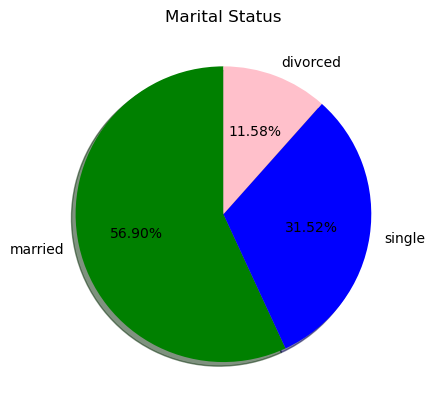

In [9]:
plt.pie(
    data['marital'].value_counts().values,
    labels= data['marital'].value_counts().index,
    colors = ['green', 'blue', 'pink'],
    autopct = "%1.2f%%",
    startangle = 90,
    shadow = True
)

plt.title(
'Marital Status'
)
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Majority of the customers are married, about 31% are single and rest are divorced.

<div>

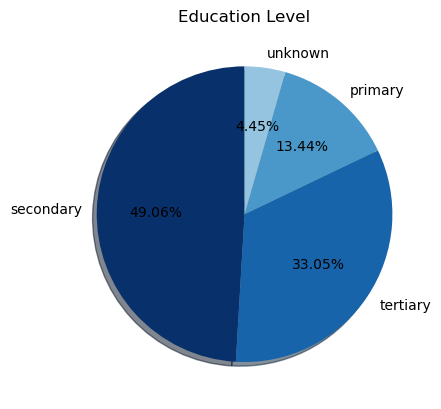

In [10]:
plt.pie(
    data['education'].value_counts().values,
    labels= data['education'].value_counts().index,
    colors = plt.cm.Blues(np.linspace(1, 0.4, 4)),
    autopct = "%1.2f%%",
    startangle = 90,
    shadow = True
)

plt.title(
'Education Level'
)
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Most of the customers have completed their secondary level. Few have completed tertiary level.

<div>

## 2.2 Financial Attributes

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Descirbes the customer's financial condition and liabilities.

In [11]:
data['balance'].describe()

count    11162.000000
mean      1528.538524
std       3225.413326
min      -6847.000000
25%        122.000000
50%        550.000000
75%       1708.000000
max      81204.000000
Name: balance, dtype: float64

In [12]:
data['balance'].skew()

np.float64(8.224619112755489)

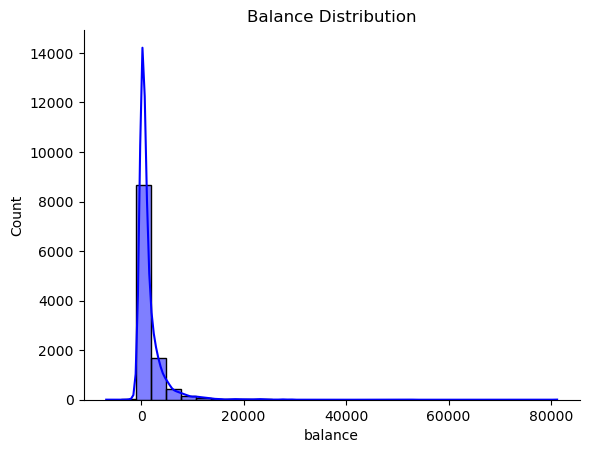

In [13]:
sns.histplot(
    data = data,
    bins = 30,
    x = 'balance',
    color = 'blue',
    kde = True
)

plt.title('Balance Distribution')
sns.despine()
plt.show()

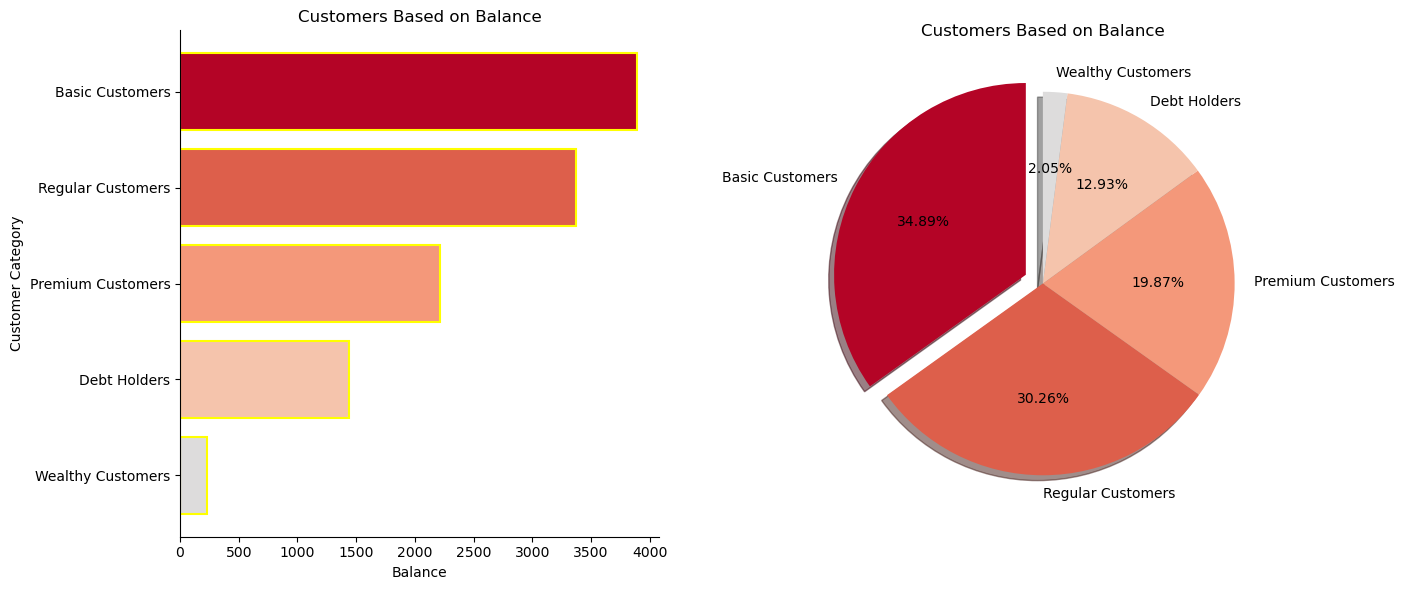

In [14]:

bins =  [-1000, 0, 500, 2000, 10000, 100000 ]
labels = ['Debt Holders', 'Basic Customers', 
        'Regular Customers', 'Premium Customers', 
        'Wealthy Customers']

data['balance_category'] = pd.cut(data['balance'], bins = bins,
                            labels = labels )


fig, ax = plt.subplots(1, 2, figsize = (14,6))

ax[0].barh(
    y = data['balance_category'].value_counts().index,
    width = data['balance_category'].value_counts().values,
    color = plt.cm.coolwarm(np.linspace(1, 0.5, 5)),
    linewidth = 1.5,
    edgecolor = 'yellow'
)

ax[0].set_title('Customers Based on Balance')
ax[0].set_ylabel('Customer Category')
ax[0].set_xlabel('Balance')
ax[0].invert_yaxis()



ax[1].pie(
    data['balance_category'].value_counts().values,
    labels = data['balance_category'].value_counts().index,
    colors = plt.cm.coolwarm(np.linspace(1, 0.5, 5)),
    autopct = '%1.2f%%',
    startangle = 90,
    shadow = True,
    explode = [0.1, 0, 0, 0, 0]
    )
ax[1].set_title('Customers Based on Balance')


plt.tight_layout()
sns.despine()
plt.subplots_adjust(wspace = 0.3)
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify"> Most of the customers are basic and regular with balance 0-2000. There are some premium customers with very high balance and few debt holders.

<div>

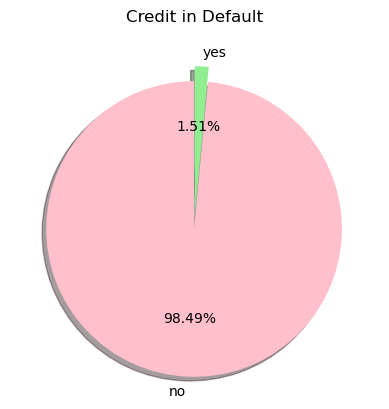

In [15]:
plt.pie(
    data['default'].value_counts().values,
    labels = data['default'].value_counts().index,
    colors = ['pink', 'lightgreen'],
    autopct = '%1.2f%%',
    startangle = 90,
    shadow = True,
    explode = [0.1, 0]
)

plt.title('Credit in Default')
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">There is very minute percentage of customers (<2%) with credit in default. These customers failed to replay loan or credit according to agreed terms, hence high risk borrowers. Rest, customers are most likely to be trusted.

</div>

<div>

<div>

In [16]:
def classify_loan(row):
    if row['housing'] == 'yes' and row['loan'] == 'yes':
        return 'Both Loans'
    elif row['housing'] == 'yes' and row['loan'] == 'no':
        return 'Housing Loan Only'
    elif row['housing'] == 'no' and row['loan'] == 'yes':
        return 'Personal Loan Only'
    else:
        return 'No Loans'

data['loan_status'] = data.apply(classify_loan, axis=1)

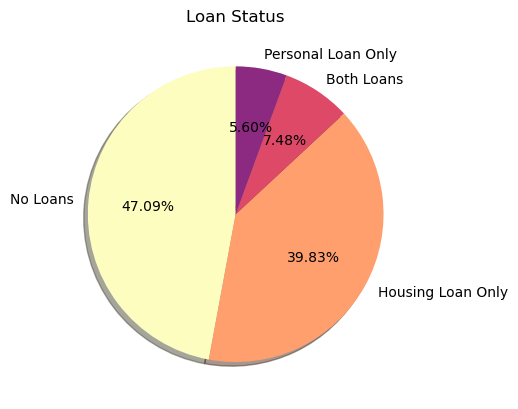

In [17]:
plt.pie(
    data['loan_status'].value_counts().values,
    labels = data['loan_status'].value_counts().index,
    colors = plt.cm.magma(np.linspace(1, 0.4, 4)),
    autopct = '%1.2f%%',
    startangle = 90,
    shadow = True,
    explode = [0, 0, 0, 0]
)




plt.title('Loan Status')
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">47% of the customers have no loan, nearly 40% have housing loan only, while 5.6% have personal loan only and rest have both loans.

<div>

## 2.3 Current Campaign Attributes

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Information about current campaign and the latest contact.

In [18]:
data['contact'].value_counts()

contact
cellular     8042
unknown      2346
telephone     774
Name: count, dtype: int64

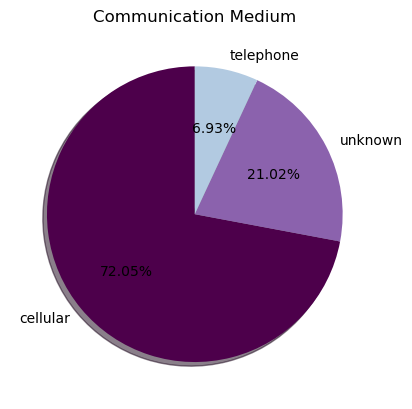

In [19]:
plt.pie(
    data['contact'].value_counts().values,
    labels = data['contact'].value_counts().index,
    autopct = '%1.2f%%',
    colors = plt.cm.BuPu(np.linspace(1, 0.3, 3)),
    startangle = 90,
    shadow = True
)

plt.title('Communication Medium')
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Majority of customers were contacted via cell phone, around 7% via telephone and rest are unknown.

<div>

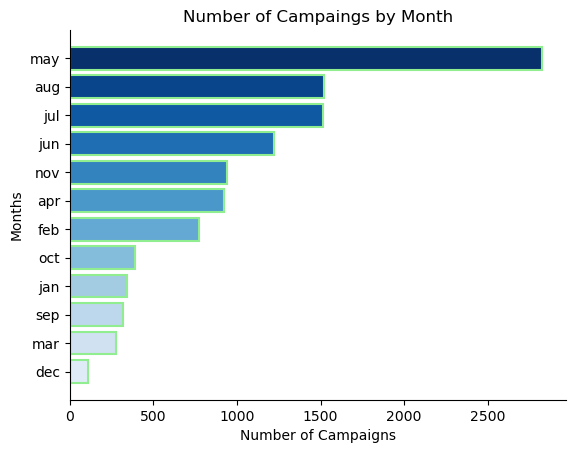

In [20]:
plt.barh(
    y = data['month'].value_counts().index,
    width = data['month'].value_counts().values,
    color = plt.cm.Blues(np.linspace(1, 0.12, 12)),
    linewidth = 1.5,
    edgecolor = 'lightgreen'
)


plt.title('Number of Campaings by Month')
plt.ylabel('Months')
plt.xlabel('Number of Campaigns')
plt.gca().invert_yaxis()
sns.despine()
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Most campaign calls were made in May.

<div>

In [21]:
data['duration'].describe()

count    11162.000000
mean       371.993818
std        347.128386
min          2.000000
25%        138.000000
50%        255.000000
75%        496.000000
max       3881.000000
Name: duration, dtype: float64

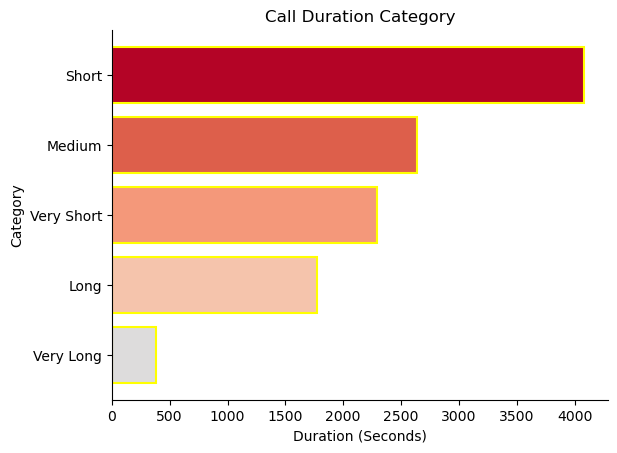

In [22]:
bins = [0, 120, 300, 600, 1200, float('inf')]
labels = ['Very Short', 'Short', 'Medium', 'Long', 'Very Long']

data['duration_group'] = pd.cut(
    data['duration'],
    bins=bins,
    labels=labels
)

plt.barh(
    y = data['duration_group'].value_counts().index,
    width = data['duration_group'].value_counts().values,
    color = plt.cm.coolwarm(np.linspace(1, 0.5, 5)),
    linewidth = 1.5,
    edgecolor = 'yellow'
)

plt.title('Call Duration Category')
plt.ylabel('Category')
plt.xlabel('Duration (Seconds)')
plt.gca().invert_yaxis()
sns.despine()
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify"> Most of the calls lasted for short duration 2-3 minutes. 

<div>

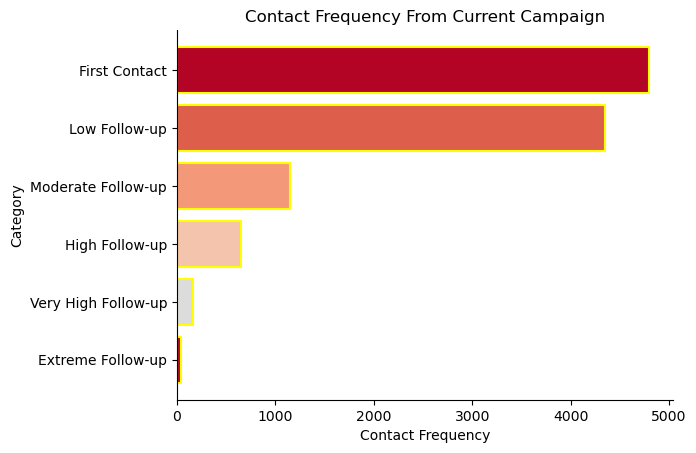

In [29]:
bins = [0, 1, 3, 5, 10, 20, float('inf')]

labels = [
    'First Contact',
    'Low Follow-up',
    'Moderate Follow-up',
    'High Follow-up',
    'Very High Follow-up',
    'Extreme Follow-up'
]

data['campaign_group'] = pd.cut(
    data['campaign'],
    bins=bins,
    labels=labels
)


plt.barh(
    y = data['campaign_group'].value_counts().index,
    width = data['campaign_group'].value_counts().values,
    color = plt.cm.coolwarm(np.linspace(1, 0.5, 5)),
    linewidth = 1.5,
    edgecolor = 'yellow'
)

plt.title('Contact Frequency From Current Campaign')
plt.ylabel('Category')
plt.xlabel('Contact Frequency')
plt.gca().invert_yaxis()
sns.despine()
plt.show()



<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Most of the customers were contacted only once during current marketing campaing.

<div>

<div>

## 2.4 Previous Campaign Attributes

In [24]:
data['pdays'].describe()

count    11162.000000
mean        51.330407
std        108.758282
min         -1.000000
25%         -1.000000
50%         -1.000000
75%         20.750000
max        854.000000
Name: pdays, dtype: float64

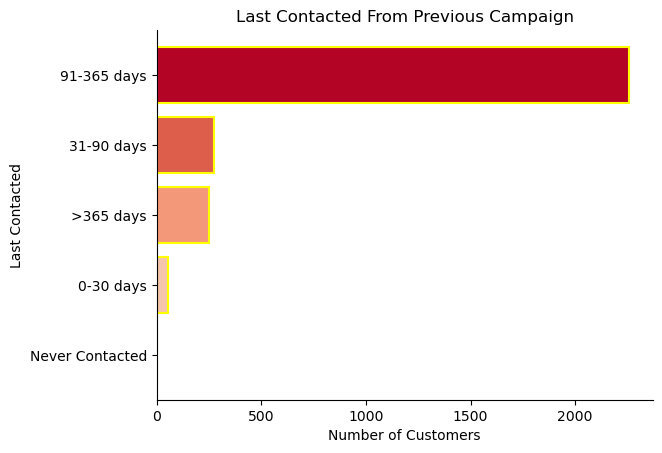

In [25]:
bins = [-1, 0, 30, 90, 365, float('inf')]

labels = [
    'Never Contacted',
    '0-30 days',
    '31-90 days',
    '91-365 days',
    '>365 days'
]

data['pdays_group'] = pd.cut(
    data['pdays'],
    bins=bins,
    labels=labels
)


plt.barh(
    y = data['pdays_group'].value_counts().index,
    width = data['pdays_group'].value_counts().values,
    color = plt.cm.coolwarm(np.linspace(1, 0.5, 5)),
    linewidth = 1.5,
    edgecolor = 'yellow'
)

plt.title('Last Contacted From Previous Campaign')
plt.ylabel('Last Contacted')
plt.xlabel('Number of Customers')
plt.gca().invert_yaxis()
sns.despine()
plt.show()



<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Only few customers were contacted recently from the previous campaign. Also, the customers were contacted at least once.

<div>

<div>

In [27]:
data['previous'].describe()

count    11162.000000
mean         0.832557
std          2.292007
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max         58.000000
Name: previous, dtype: float64

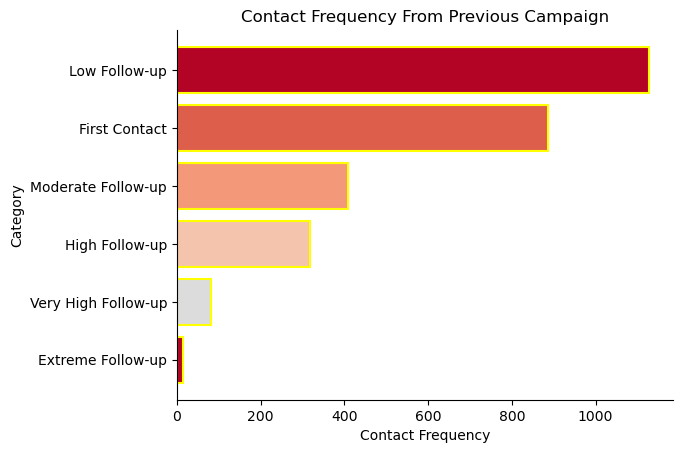

In [30]:
bins = [0, 1, 3, 5, 10, 20, float('inf')]

labels = [
    'First Contact',
    'Low Follow-up',
    'Moderate Follow-up',
    'High Follow-up',
    'Very High Follow-up',
    'Extreme Follow-up'
]

data['previous_group'] = pd.cut(
    data['previous'],
    bins=bins,
    labels=labels
)


plt.barh(
    y = data['previous_group'].value_counts().index,
    width = data['previous_group'].value_counts().values,
    color = plt.cm.coolwarm(np.linspace(1, 0.5, 5)),
    linewidth = 1.5,
    edgecolor = 'yellow'
)

plt.title('Contact Frequency From Previous Campaign')
plt.ylabel('Category')
plt.xlabel('Contact Frequency')
plt.gca().invert_yaxis()
sns.despine()
plt.show()



<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Majority of the customers were contacted only once from the previous marketing campaign. 

<div>

In [32]:
data['poutcome'].value_counts()

poutcome
unknown    8326
failure    1228
success    1071
other       537
Name: count, dtype: int64

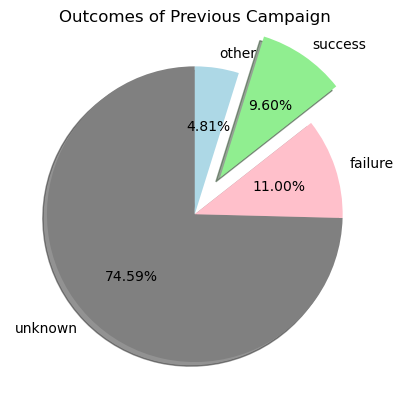

In [34]:
plt.pie(
    data['poutcome'].value_counts().values,
    labels = data['poutcome'].value_counts().index,
    colors = ['grey', 'pink', 'lightgreen', 'lightblue'],
    startangle = 90,
    autopct = '%1.2f%%',
    shadow = True,
    explode = [0, 0, 0.3, 0]
)

plt.title('Outcomes of Previous Campaign')
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify"> The success rate of previous campaing was just 9.6%.

<div>

## 2.5 Deposit (Target Variable)

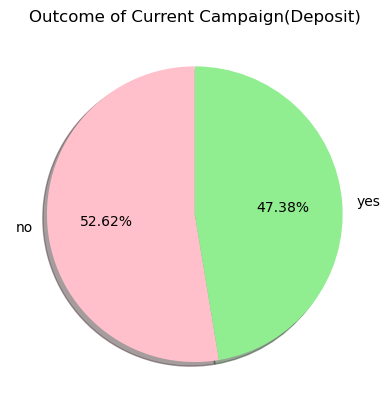

In [36]:
plt.pie(
    data['deposit'].value_counts().values,
    labels = data['deposit'].value_counts().index,
    colors = ['pink', 'lightgreen'],
    autopct = '%1.2f%%',
    startangle = 90,
    shadow = True)

plt.title('Outcome of Current Campaign(Deposit)')
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">The success rate of current campaign is pretty high compared to the previous one, with hike of 37.8%.

<div>

<div>

# 3. Bivariate Analysis

## 3.1 